In [1]:
%load_ext autoreload
%autoreload 2

In [48]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from constants import CALCEDatasetConstants, MODEL_OUTPUT_PATH
from preprocessing_functions import generate_sliding_window_data
from models import TCN_GRU_DNN_Model, BiLSTM_Attention, abc_algorithm, BiGRUModel, CNN_DBLSTM_Model, CNN_ASTLSTM

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Loading the Data

In [4]:
PROCESSED_BATTERY_PATHS = [CALCEDatasetConstants.BATTERY_PROCESSED_PATH.value / (battery_name+'.csv') for battery_name in CALCEDatasetConstants.BATTERY_NAMES.value]
PROCESSED_BATTERY_PATHS

[WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_35.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_36.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_37.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_38.csv')]

In [5]:
dfs = {CALCEDatasetConstants.BATTERY_NUMBERS.value[i]: \
       pd.read_csv(PROCESSED_BATTERY_PATHS[i]).drop(['Unnamed: 0'], axis=1) for i in range(len(CALCEDatasetConstants.BATTERY_NUMBERS.value))}
dfs

{35:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.123221
 1              2                1.111035
 2              3                1.106058
 3              4                1.102627
 4              5                1.098143
 ..           ...                     ...
 757          758                0.332357
 758          759                0.328566
 759          760                0.325232
 760          761                0.322707
 761          762                0.319955
 
 [762 rows x 2 columns],
 36:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.134613
 1              2                1.124949
 2              3                1.121679
 3              4                1.119217
 4              5                1.115648
 ..           ...                     ...
 768          769                0.173019
 769          770                0.169924
 770          771                0.168700
 771          772                0.168793

# Visualizing the data along with train test split

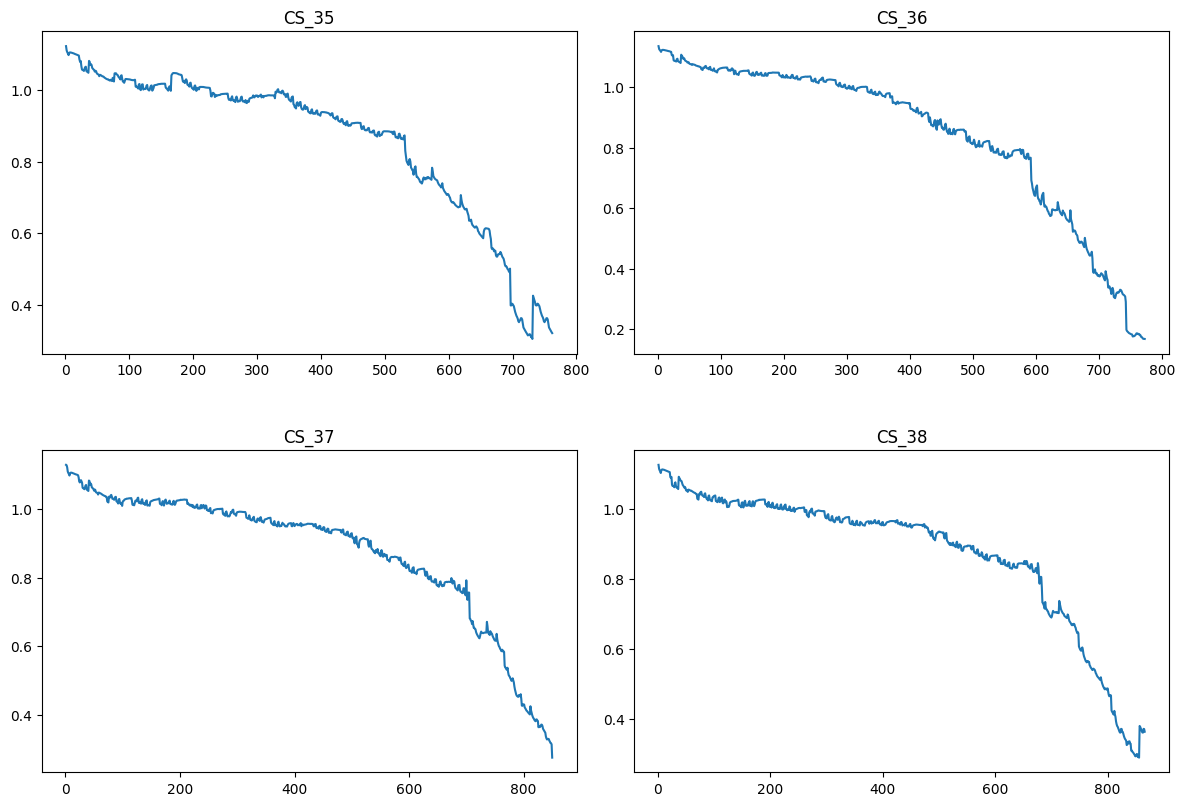

In [6]:
fig, ax = plt.subplots(nrows=int(len(dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(dfs.items()):
    ax[int(i/2), i%2].plot(df['Cycle_Index'], df['Discharge_Capacity(Ah)'])
    ax[int(i/2), i%2].set_title(f'CS_{battery_number}')

plt.show()

In [7]:
TRAINING_BATTERIES = CALCEDatasetConstants.BATTERY_NUMBERS.value[:3]
TEST_BATTERY = CALCEDatasetConstants.BATTERY_NUMBERS.value[3]

In [8]:
x, y = generate_sliding_window_data(dfs[TRAINING_BATTERIES[0]]['Discharge_Capacity(Ah)'])
x.shape, y.shape

((752, 10), (752,))

In [9]:
x.shape, y.shape

((752, 10), (752,))

In [10]:
trainX = []
trainY = []

for battery in TRAINING_BATTERIES:
    x, y = generate_sliding_window_data(dfs[battery]['Discharge_Capacity(Ah)'])
    trainX.extend(x)
    trainY.extend(y)

trainX, trainY = np.array(trainX), np.array(trainY)
trainX.shape, trainY.shape

((2355, 10), (2355,))

In [11]:
testX, testY = generate_sliding_window_data(dfs[TEST_BATTERY]['Discharge_Capacity(Ah)'])
testX, testY = np.array(testX), np.array(testY)
testX.shape, testY.shape

((856, 10), (856,))

In [12]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx]

In [13]:
train_dataset = CustomDataset(trainX, trainY)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [14]:
test_dataset = CustomDataset(testX, testY)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [49]:
def train_step(model, x, y, optimizer, criterion, device, min, diff):
    """
    Perform a single training step.

    Args:
        model (torch.nn.Module): The model to train.
        x (torch.Tensor): Input data.
        y (torch.Tensor): Target data.
        optimizer (torch.optim.Optimizer): Optimizer for updating model parameters.
        criterion (torch.nn.Module): Loss function.
        device (torch.device): Device to run the computations on (e.g., 'cpu' or 'cuda').
        min_val (float): Minimum value for normalization.
        diff_val (float): Difference (range) for normalization.

    Returns:
        float: The loss value for the step.
    """
    x = (x - min) / diff
    y = (y - min) / diff

    optimizer.zero_grad()

    predictions = model(x.to(device))
    predictions = predictions.view(-1)

    loss = criterion(predictions, y.to(device))

    loss.backward()
    optimizer.step()

    return loss.item()

def test_step(model, x, y, criterion, device, min, diff):
    """
    Perform a single testing step.

    Args:
        model (torch.nn.Module): The model to evaluate.
        x (torch.Tensor): Input data.
        y (torch.Tensor): Target data.
        criterion (torch.nn.Module): Loss function.
        device (torch.device): Device to run the computations on (e.g., 'cpu' or 'cuda').
        min_val (float): Minimum value for normalization.
        diff_val (float): Difference (range) for normalization.

    Returns:
        float: The loss value for the step.
    """

    x = (x - min) / diff
    y = (y - min) / diff

    model.eval()

    with torch.no_grad():
        predictions = model(x.to(device))
        predictions = predictions.view(-1)

        loss = criterion(predictions, y.to(device))

    return loss.item()

def evaluate_model(model, dataloader, device, MIN, DIFF, unsqueeze_dim=1):
    """
    Evaluate a PyTorch model using RMSE and MAE on a given dataset.

    Parameters:
    - model (torch.nn.Module): The model to evaluate.
    - dataloader (torch.utils.data.DataLoader): DataLoader for the test dataset.
    - device (torch.device): The device to run the model on (e.g., 'cpu' or 'cuda').
    - MIN (float): Minimum value for normalization (if applicable).
    - DIFF (float): Difference value for normalization (if applicable).
    - unsqueeze_dim (int): Dimension to unsqueeze the input tensor (default is 1).

    Returns:
    - dict: A dictionary containing RMSE and MAE values.
    """
    # Define loss functions
    criterion_1 = torch.nn.MSELoss(reduction='sum')
    criterion_2 = torch.nn.L1Loss(reduction='sum')
    
    model.eval()
    total_samples = len(dataloader.dataset)
    test_loss_mse = 0.0
    test_loss_mae = 0.0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.unsqueeze(unsqueeze_dim)  # Apply unsqueeze with the given dimension
            test_loss_mse += test_step(model, x, y, criterion_1, device, MIN, DIFF)
            test_loss_mae += test_step(model, x, y, criterion_2, device, MIN, DIFF)

    avg_test_loss_mse = test_loss_mse / total_samples
    test_loss_rmse = np.sqrt(avg_test_loss_mse)
    avg_test_loss_mae = test_loss_mae / total_samples

    return {
        "RMSE": test_loss_rmse,
        "MAE": avg_test_loss_mae
    }

def plot_predictions(
    model, 
    dfs, 
    test_battery, 
    generate_sliding_window_data, 
    min_val, 
    diff_val, 
    device, 
    unsqueeze_dim=1, 
    cutoff_percentage=30
):
    """
    Generates predictions for the test curve using the given model and plots the results.

    Args:
        model (torch.nn.Module): Trained model for predictions.
        dfs (dict): Dictionary containing battery dataframes.
        test_battery (str): Key for the battery data in the dfs dictionary.
        generate_sliding_window_data (callable): Function to generate sliding window data.
        min_val (float): Minimum value used for normalization.
        diff_val (float): Range (difference) used for normalization.
        device (torch.device): Device for computation (e.g., 'cuda' or 'cpu').
        unsqueeze_dim (int, optional): Dimension to unsqueeze before passing to the model. Defaults to 1.
        cutoff_percentage (int, optional): Percentage to determine the cutoff cycle. Defaults to 30.
    
    Returns:
        None
    """
    # Determine cutoff cycle based on percentage
    cutoff_cycle = int(cutoff_percentage * dfs[test_battery].shape[0] / 100)
    
    # Split initial and test curves
    initial = dfs[test_battery].loc[:cutoff_cycle, 'Discharge_Capacity(Ah)'].values
    test_curve = dfs[test_battery].loc[cutoff_cycle:, 'Discharge_Capacity(Ah)'].values

    sliding_windows = generate_sliding_window_data(np.append(initial[-10:], test_curve))[0]

    model.eval()

    with torch.no_grad():
        sliding_windows_scaled = (sliding_windows - min_val) / diff_val

        predictions = model(torch.tensor(sliding_windows_scaled).unsqueeze(unsqueeze_dim).to(device))
        predictions = predictions * diff_val + min_val
        predictions = predictions.flatten()


    cycle_indices = np.arange(1, initial.shape[0] + test_curve.shape[0] + 1)
    cycle_indices_before = cycle_indices[:cutoff_cycle + 1]
    cycle_indices_after = cycle_indices[cutoff_cycle + 1:]

    plt.figure(figsize=(10, 6))
    plt.plot(cycle_indices_before, initial[:cutoff_cycle + 1], label="Initial Data", color="blue")
    plt.plot(cycle_indices_after, test_curve, label="True Test Curve", color="green")
    plt.plot(cycle_indices_after, predictions.cpu(), label="Predictions", color="red", linestyle="--")
    plt.xlabel("Cycle Index")
    plt.ylabel("Discharge Capacity (Ah)")
    plt.title("Predicted vs Actual Discharge Capacity")
    plt.legend()
    plt.grid()
    plt.show()

def save_model(model, path, save_state_dict=True):
    """
    Saves a PyTorch model to the specified path.

    Parameters:
    - model (torch.nn.Module): The model to save.
    - path (str): The file path to save the model (e.g., 'model.pth').
    - save_state_dict (bool): If True, saves only the state_dict. If False, saves the entire model.

    Returns:
    None
    """
    if save_state_dict:
        # Save only the model's state_dict
        torch.save(model.state_dict(), path)
        print(f"Model's state_dict saved to {path}")
    else:
        # Save the entire model
        torch.save(model, path)
        print(f"Entire model saved to {path}")

In [16]:
MAX = 1.1
MIN = 0.0
DIFF = MAX - MIN

## TCN-GRU-DNN Model

In [17]:
model_1 = TCN_GRU_DNN_Model().to(device)
optimizer = torch.optim.Adam(model_1.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 25


for epoch in range(EPOCHS):
    epoch_loss = 0.0
    model_1.train()
    
    for x, y in train_dataloader:
        loss_item = train_step(model_1, x.unsqueeze(1), y, optimizer, criterion, device, MIN, DIFF)
        epoch_loss += loss_item

    avg_loss = epoch_loss / len(train_dataloader)
    if epoch%1 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss}")

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1/25, Loss: 0.6889540726268614
Epoch 2/25, Loss: 0.0776382605922786
Epoch 3/25, Loss: 0.03710197911572617
Epoch 4/25, Loss: 0.03463386213155212
Epoch 5/25, Loss: 0.025475545081536512
Epoch 6/25, Loss: 0.005068211619603775
Epoch 7/25, Loss: 0.0012318393324873083
Epoch 8/25, Loss: 0.0008852517911126031
Epoch 9/25, Loss: 0.0007706265078505148
Epoch 10/25, Loss: 0.0006708504606157894
Epoch 11/25, Loss: 0.0005458830379899843
Epoch 12/25, Loss: 0.0005070710691585633
Epoch 13/25, Loss: 0.00044983677562905123
Epoch 14/25, Loss: 0.0004169180540122545
Epoch 15/25, Loss: 0.00040623168594745065
Epoch 16/25, Loss: 0.00038517740668376555
Epoch 17/25, Loss: 0.00038110724081225517
Epoch 18/25, Loss: 0.0003498027345395295
Epoch 19/25, Loss: 0.0003269007369503064
Epoch 20/25, Loss: 0.000286065192159259
Epoch 21/25, Loss: 0.0002988744043348659
Epoch 22/25, Loss: 0.00030034798721710496
Epoch 23/25, Loss: 0.00027294822900109247
Epoch 24/25, Loss: 0.00028641924861428405
Epoch 25/25, Loss: 0.0002696171

In [22]:
metrics = evaluate_model(model_1, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.012756613215726428
MAE: 0.009307434590898942


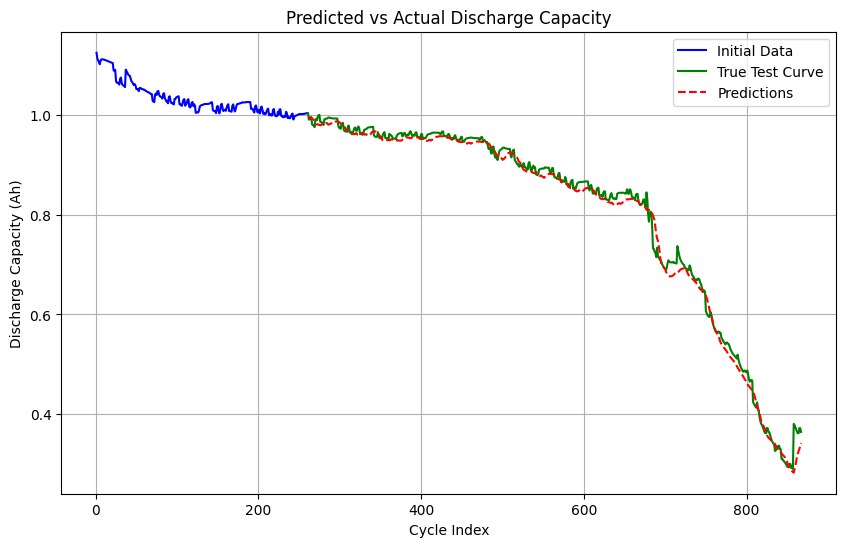

In [24]:
plot_predictions(model_1, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 1, 30)

In [50]:
save_model(model_1, MODEL_OUTPUT_PATH / 'tcn_gru_dnn.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\tcn_gru_dnn.pth


## BiLSTM Attention Model

In [27]:
model_2 = BiLSTM_Attention(128).to(device)
optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
EPOCHS = 25

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    model_2.train()
    
    for x, y in train_dataloader:
        loss_item = train_step(model_2, x.unsqueeze(-1), y, optimizer, criterion, device, MIN, DIFF)
        epoch_loss += loss_item

    avg_loss = epoch_loss / len(train_dataloader)
    if epoch%1 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss}")

Epoch 1/25, Loss: 0.08538466359715204
Epoch 2/25, Loss: 0.006842955294445887
Epoch 3/25, Loss: 0.00040448869618263123
Epoch 4/25, Loss: 0.0006900823889835108
Epoch 5/25, Loss: 0.0002644923019574521
Epoch 6/25, Loss: 0.0002738564793174659
Epoch 7/25, Loss: 0.00026172815769559993
Epoch 8/25, Loss: 0.000237634333569912
Epoch 9/25, Loss: 0.0005777149305956571
Epoch 10/25, Loss: 0.0005616832959522317
Epoch 11/25, Loss: 0.0003817623591866986
Epoch 12/25, Loss: 0.0004454080582847284
Epoch 13/25, Loss: 0.0005127360640767005
Epoch 14/25, Loss: 0.00032190558817387065
Epoch 15/25, Loss: 0.00025542721335581074
Epoch 16/25, Loss: 0.0003213207994515353
Epoch 17/25, Loss: 0.0004921991957589116
Epoch 18/25, Loss: 0.00025613459149246556
Epoch 19/25, Loss: 0.00040265302910434865
Epoch 20/25, Loss: 0.0004884641818805265
Epoch 21/25, Loss: 0.0002897764602125421
Epoch 22/25, Loss: 0.0002008972697276968
Epoch 23/25, Loss: 0.0002966010025694551
Epoch 24/25, Loss: 0.0006283369238607938
Epoch 25/25, Loss: 0.00

In [28]:
metrics = evaluate_model(model_2, test_dataloader, device, MIN, DIFF, -1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.015000563033319418
MAE: 0.011119087479103392


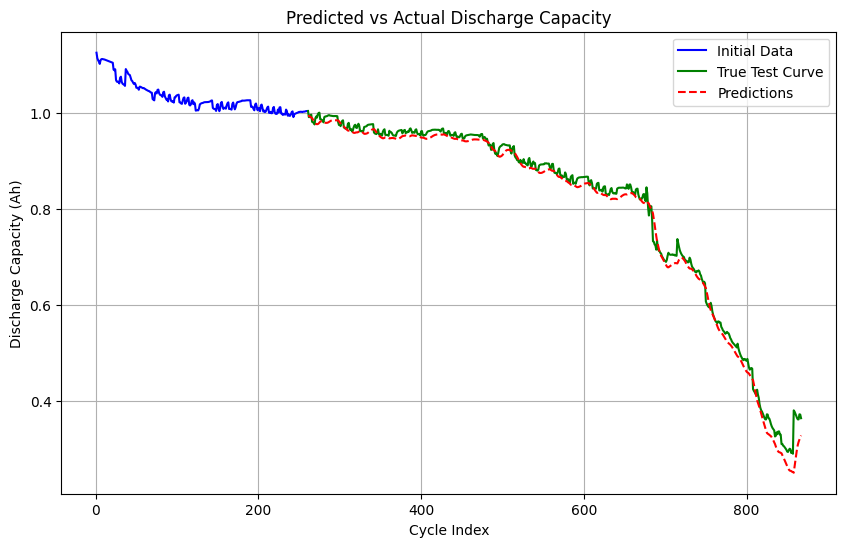

In [29]:
plot_predictions(model_2, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, -1, 30)

In [51]:
save_model(model_2, MODEL_OUTPUT_PATH / 'attn_bilstm.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\attn_bilstm.pth


## ABC (Artificial Bee Colony) BiGRU Model

In [34]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, train_dataloader, test_dataloader, device, n_solutions=10, max_iters=20)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 2/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 3/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 4/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 5/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 6/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 7/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 8/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 9/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 10/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 11/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 12/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 13/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 14/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 15/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 16/20, Best Fitness (MSE): 0.00014784330064517067
Iteration 17/20, Best Fitness (MSE): 0.0001478433

In [37]:
model_3 = BiGRUModel(input_size=10, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
EPOCHS = 50

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    model_3.train()
    
    for x, y in train_dataloader:
        loss_item = train_step(model_3, x.unsqueeze(1), y, optimizer, criterion, device, MIN, DIFF)
        epoch_loss += loss_item

    avg_loss = epoch_loss / len(train_dataloader)
    if epoch%1 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss}")

Epoch 1/50, Loss: 0.06780898477882147
Epoch 2/50, Loss: 0.010346625818292031
Epoch 3/50, Loss: 0.008581176582673515
Epoch 4/50, Loss: 0.0068837099305882644
Epoch 5/50, Loss: 0.005617923653885923
Epoch 6/50, Loss: 0.005053212855174835
Epoch 7/50, Loss: 0.004771576388864903
Epoch 8/50, Loss: 0.0044737845907818425
Epoch 9/50, Loss: 0.004332308761297247
Epoch 10/50, Loss: 0.004119530505802785
Epoch 11/50, Loss: 0.004165286692236927
Epoch 12/50, Loss: 0.003933225418566852
Epoch 13/50, Loss: 0.003908275791783692
Epoch 14/50, Loss: 0.003680563528669646
Epoch 15/50, Loss: 0.0038006785781928214
Epoch 16/50, Loss: 0.003606408944579999
Epoch 17/50, Loss: 0.003523702546010247
Epoch 18/50, Loss: 0.0037520976762312488
Epoch 19/50, Loss: 0.0033545809612307393
Epoch 20/50, Loss: 0.0031731815747539135
Epoch 21/50, Loss: 0.0031363534870104412
Epoch 22/50, Loss: 0.002952610472896816
Epoch 23/50, Loss: 0.002978630579466856
Epoch 24/50, Loss: 0.003179272570697641
Epoch 25/50, Loss: 0.0029587713447777
Epoch

In [38]:
metrics = evaluate_model(model_3, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.009830800628651262
MAE: 0.006964301394524975


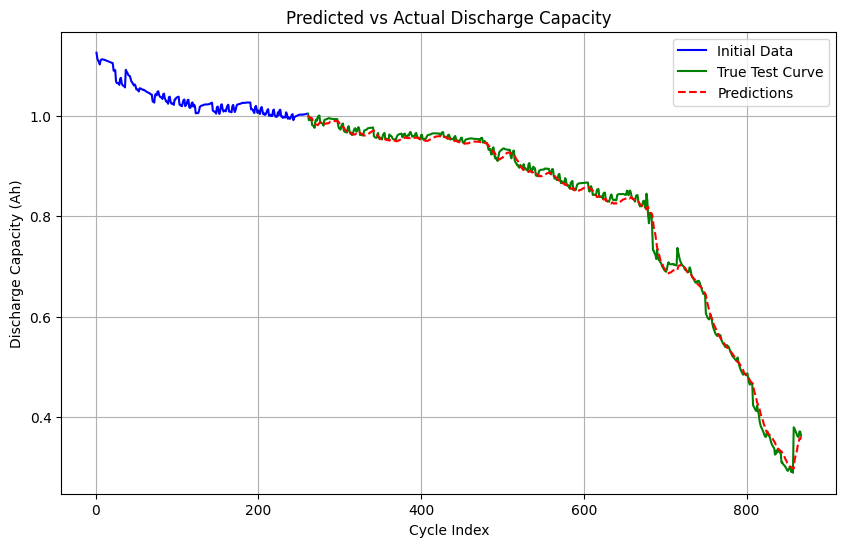

In [39]:
plot_predictions(model_3, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 1, 30)

In [52]:
save_model(model_3, MODEL_OUTPUT_PATH / 'abc_bigru.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\abc_bigru.pth


## CNN - DBLSTM Model

In [42]:
model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
optimizer = torch.optim.Adam(model_4.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 10


for epoch in range(EPOCHS):
    epoch_loss = 0.0
    model_4.train()
    
    for x, y in train_dataloader:
        loss_item = train_step(model_4, x.unsqueeze(1), y, optimizer, criterion, device, MIN, DIFF)
        epoch_loss += loss_item

    avg_loss = epoch_loss / len(train_dataloader)
    if epoch%1 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss}")

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv1d(


Epoch 1/10, Loss: 0.1462204654770274
Epoch 2/10, Loss: 0.002646517292895304
Epoch 3/10, Loss: 0.0012300311303791917
Epoch 4/10, Loss: 0.0009315880365524994
Epoch 5/10, Loss: 0.0006750462530731425
Epoch 6/10, Loss: 0.0005612208656325616
Epoch 7/10, Loss: 0.0005151846124479906
Epoch 8/10, Loss: 0.0004570759799232316
Epoch 9/10, Loss: 0.000729359995946996
Epoch 10/10, Loss: 0.0006697021156936456


In [43]:
metrics = evaluate_model(model_4, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.012457769072490365
MAE: 0.010380441096620025


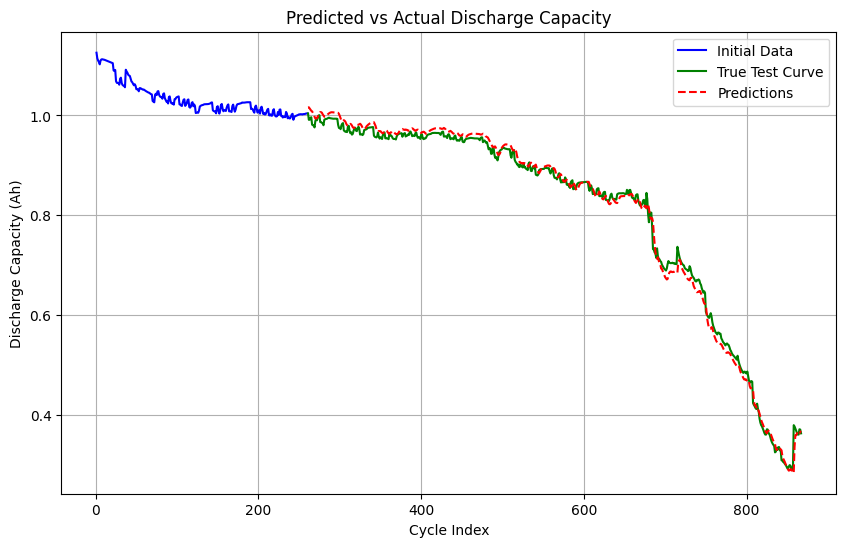

In [44]:
plot_predictions(model_4, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 1, 30)

In [53]:
save_model(model_4, MODEL_OUTPUT_PATH / 'cnn_dblstm.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\cnn_dblstm.pth


## CNN - ASTLSTM

In [45]:
model_5 = CNN_ASTLSTM(64, 128).to(device)
optimizer = torch.optim.Adam(model_5.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 10


for epoch in range(EPOCHS):
    epoch_loss = 0.0
    model_5.train()
    
    for x, y in train_dataloader:
        loss_item = train_step(model_5, x.unsqueeze(1), y, optimizer, criterion, device, MIN, DIFF)
        epoch_loss += loss_item

    avg_loss = epoch_loss / len(train_dataloader)
    if epoch%1 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss}")

Epoch 1/10, Loss: 0.07523793349596294
Epoch 2/10, Loss: 0.007996429041275012
Epoch 3/10, Loss: 0.00018305705998500343
Epoch 4/10, Loss: 0.00014084913748996082
Epoch 5/10, Loss: 0.00012758668251351351
Epoch 6/10, Loss: 0.000129319074010316
Epoch 7/10, Loss: 0.00015258024944381072
Epoch 8/10, Loss: 0.00014861169059971675
Epoch 9/10, Loss: 0.00014704668776814928
Epoch 10/10, Loss: 0.00010488565985232944


In [46]:
metrics = evaluate_model(model_5, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.008967455156062032
MAE: 0.006156276511115448


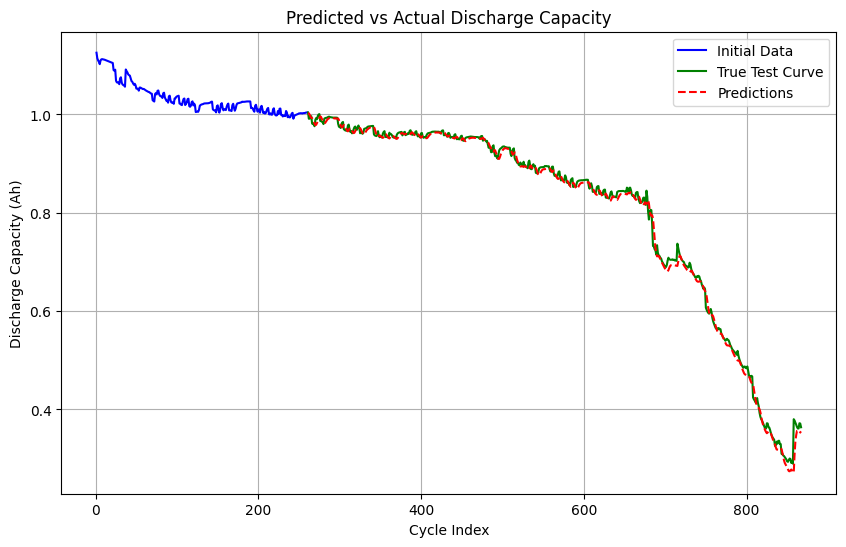

In [47]:
plot_predictions(model_5, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 1, 30)

In [54]:
save_model(model_5, MODEL_OUTPUT_PATH / 'cnn_astlstm.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\cnn_astlstm.pth
